In [ ]:
!pip install -q datasets sentencepiece sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.0/128.0 kB 15.1 MB/s eta 0:00:00


In [ ]:
import re
import random
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import sentencepiece as spm
import sacrebleu

from datasets import load_dataset
from tensorflow.keras import layers
from tqdm.auto import tqdm

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

RAW_POOL_SIZE = 250_000
NUM_TRAIN = 100_000

VOCAB_SIZE = 30_000

MIN_WORDS = 2

DATA_DIR = Path("/content/nmt_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = Path("/content/nmt_checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
dataset = load_dataset(
    "Helsinki-NLP/opus-100",
    "ar-en"
)

print(dataset)

README.md:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

ar-en/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  214kB            

ar-en/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

ar-en/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 99.3MB            

ar-en/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

ar-en/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
    train: Dataset({
        features: ['translation'],
        num_rows: 1000000
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
})


In [ ]:
print("Train:", len(dataset["train"]))
print("Validation:", len(dataset["validation"]))
print("Test:", len(dataset["test"]))

print(dataset["train"][0])

Train: 1000000
Validation: 2000
Test: 2000
{'translation': {'ar': 'و هذه؟', 'en': 'And this?'}}


In [ ]:
train_data = dataset["train"]

rng = np.random.default_rng(SEED)

pool_indices = rng.choice(
    len(train_data),
    size=min(RAW_POOL_SIZE, len(train_data)),
    replace=False
)

pool_indices = pool_indices.tolist()

raw_pool = train_data.select(pool_indices)

print("Full training corpus:", len(train_data))
print("Random pool:", len(raw_pool))

Full training corpus: 1000000
Random pool: 250000


In [ ]:
def normalize_arabic(text):
    text = unicodedata.normalize("NFKC", str(text))

    text = re.sub(
        r"[\u0617-\u061A\u064B-\u0652\u0670\u06D6-\u06ED]",
        "",
        text
    )

    text = text.replace("\u0640", "")

    text = re.sub(r"\s+", " ", text).strip()

    return text


def normalize_english(text):
    text = unicodedata.normalize("NFKC", str(text))

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
clean_ar = []
clean_en = []

for row in tqdm(raw_pool, desc="Cleaning"):

    ar = normalize_arabic(
        row["translation"]["ar"]
    )

    en = normalize_english(
        row["translation"]["en"]
    )

    if not ar or not en:
        continue

    clean_ar.append(ar)
    clean_en.append(en)

print("Pairs after basic cleaning:", len(clean_ar))

Cleaning:   0%|          | 0/250000 [00:00<?, ?it/s]

Pairs after basic cleaning: 249981


In [ ]:
df = pd.DataFrame({
    "english": clean_en,
    "arabic": clean_ar
})

before = len(df)

df = df.drop_duplicates(
    subset=["english", "arabic"]
).reset_index(drop=True)

print("Before:", before)
print("After:", len(df))
print("Removed:", before - len(df))

Before: 249981
After: 243595
Removed: 6386


In [ ]:
df["english_words"] = (
    df["english"]
    .str.split()
    .str.len()
)

df["arabic_words"] = (
    df["arabic"]
    .str.split()
    .str.len()
)

print("English statistics")
print(df["english_words"].describe())

print("\nArabic statistics")
print(df["arabic_words"].describe())

English statistics
count    243595.000000
mean         10.340582
std          11.976983
min           1.000000
25%           4.000000
50%           7.000000
75%          12.000000
max         591.000000
Name: english_words, dtype: float64

Arabic statistics
count    243595.000000
mean          8.758279
std          18.557920
min           1.000000
25%           3.000000
50%           6.000000
75%           9.000000
max        5910.000000
Name: arabic_words, dtype: float64


In [ ]:
def length_statistics(series, name):

    values = series.to_numpy()

    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)

    print(f"\n{name}")
    print("-" * 50)
    print(f"Mean:   {values.mean():.2f}")
    print(f"Median: {np.median(values):.2f}")
    print(f"Std:    {values.std():.2f}")
    print(f"Min:    {values.min()}")
    print(f"Max:    {values.max()}")
    print(f"P90:    {np.percentile(values, 90):.2f}")
    print(f"P95:    {np.percentile(values, 95):.2f}")
    print(f"P98:    {np.percentile(values, 98):.2f}")
    print(f"P99:    {np.percentile(values, 99):.2f}")
    print(f"Q1:     {q1:.2f}")
    print(f"Q3:     {q3:.2f}")
    print(f"IQR:    {q3 - q1:.2f}")
    print(f"IQR upper bound: {q3 + 1.5 * (q3 - q1):.2f}")


length_statistics(
    df["english_words"],
    "English"
)

length_statistics(
    df["arabic_words"],
    "Arabic"
)


English
--------------------------------------------------
Mean:   10.34
Median: 7.00
Std:    11.98
Min:    1
Max:    591
P90:    22.00
P95:    33.00
P98:    47.00
P99:    58.00
Q1:     4.00
Q3:     12.00
IQR:    8.00
IQR upper bound: 24.00

Arabic
--------------------------------------------------
Mean:   8.76
Median: 6.00
Std:    18.56
Min:    1
Max:    5910
P90:    19.00
P95:    29.00
P98:    41.00
P99:    51.00
Q1:     3.00
Q3:     9.00
IQR:    6.00
IQR upper bound: 18.00


In [ ]:
df["length_ratio"] = (
    df["arabic_words"] /
    df["english_words"].clip(lower=1)
)

print(df["length_ratio"].describe())

print("\nRatio percentiles:")

for p in [90, 95, 98, 99]:
    print(
        f"P{p}: "
        f"{np.percentile(df['length_ratio'], p):.3f}"
    )

count    243595.000000
mean          0.916047
std           0.590642
min           0.025000
25%           0.666667
50%           0.833333
75%           1.000000
max          48.000000
Name: length_ratio, dtype: float64

Ratio percentiles:
P90: 1.314
P95: 1.556
P98: 2.000
P99: 3.000


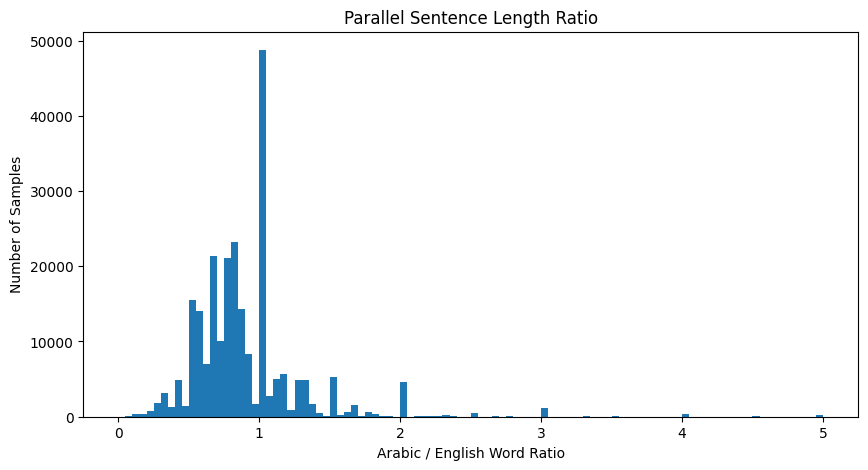

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["length_ratio"],
    bins=100,
    range=(0, 5)
)

plt.xlabel("Arabic / English Word Ratio")
plt.ylabel("Number of Samples")
plt.title("Parallel Sentence Length Ratio")
plt.show()

In [ ]:
extreme_samples = df.sort_values(
    "length_ratio",
    ascending=False
).head(20)

pd.set_option(
    "display.max_colwidth",
    200
)

extreme_samples[
    [
        "english",
        "arabic",
        "english_words",
        "arabic_words",
        "length_ratio"
    ]
]

,english,arabic,english_words,arabic_words,length_ratio
153038,No.,ستكون هناك مشاورات غير رسمية مفتوحة بشأن مشاريع القرارات المقدمة في إطار البند 117 من جدول الأعمال (القضاء على العنصرية والتمييز العنصري)، تعقدها مجموعة ال 77، اليوم، 15 شباط/فبراير 2002 في قاعة ا...,1,48,48.000000
215748,Grenada,8- وبناء على دعوة من الرئيس، أحاط مؤتمر الأطراف علما أيضا بأن 35 دولة قد صدقت على بروتوكول كيوتو أو انضمت إليه حتى 11 حزيران/يونيه 2001، وأن الوديع قد أبلغ الأمانة بأن فانواتو قد انضمت إلى بروتوكو...,1,42,42.000000
229358,Corrigendum,أعرب رئيس الجمعية العامة، نيابة عن الجمعية العامة، عن مشاعر التعاطف العميقة لكل من بوليفيا والسلفادور، حكومة وشعبا، للخسائر المأساوية في الأرواح والأضرار المادية البالغة التي نجمت عن الفيضانات الت...,1,40,40.000000
151806,or orders piety ?,أرأيت أعجب من طغيان هذا الرجل ( وهو أبو جهل ) الذي ينهى عبدا لنا إذا صلى لربه ( وهو محمد صلى الله عليه وسلم ) ؟ أرأيت إن كان المنهي عن الصلاة على الهدى فكيف ينهاه ؟ أو إن كان آمرا غيره بالتقوى أين...,4,148,37.000000
165777,HSP/GC/20/L.16/Rev,3 - يطلب إلى المديرة التنفيذية أن تضع برنامجا تدريبيا للسلطات البلدية بشأن إدارة التنمية المستدامة في المدن والمستوطنات البشرية الكبيرة وخلق قاعدة بيانات إلكترونية بشأن حالة مدن منتقاة في الشمال ا...,1,34,34.000000
224955,bw,"You are about to translate the 'Direction' COMMAND, there are some rules on how to translate it. Please see http: // edu. kde. org/ kturtle/ translator. php to learn how to properly translate it.",1,34,34.000000
81914,Ambassador,"ينشئ المؤتمر، طوال مدة الدورة الحالية، لجنة مخصصة في إطار البند 3 من جدول الأعمال المعنون ""منع حدوث سباق تسلح في الفضاء الخارجي"" لكي تتناول مسألة منع حدوث سباق تسلح في الفضاء الخارجي.",1,33,33.000000
126767,Notes,(ج) قررت الجمعية العامة أن تزيد تدريجيا النسبة التي تدفعها جمهورية كوريا لعمليات حفظ السلام اعتبارا من 1 تموز/يوليه 2002 بحيث تسدد نسبة 100 في المائة من معدل الميزانية العادية في عام 2005.,1,33,33.000000
188583,Reservations,وإذ تستند في عملها إلى أحكام الاتفاقية الدولية للقضاء على جميع أشكال التمييز العنصري التي تتوخى القضاء على التمييز بسبب العرق أو اللون أو النسب أو الأصل القومي أو الإثني،,1,30,30.000000
229446,Idem.,(ج) الخطوات التي اتخذت لمواءمة القوانين الوطنية المتعلقة بالهجرة مع أحكام الاتفاقية، ومن ذلك بيان ما إذا كانت للدولة الطرف خطط لسحب تحفظاتها على الاتفاقية، إن كان لها تحفظات؛,1,29,29.000000


In [ ]:
df["symmetric_ratio"] = np.maximum(
    df["arabic_words"] / df["english_words"].clip(lower=1),
    df["english_words"] / df["arabic_words"].clip(lower=1)
)

print(df["symmetric_ratio"].describe())

count    243595.000000
mean          1.476633
std           0.783695
min           1.000000
25%           1.111111
50%           1.300000
75%           1.571429
max          48.000000
Name: symmetric_ratio, dtype: float64


In [ ]:
for max_words in [30, 40, 50, 60]:

    mask = (
        (df["english_words"] >= 2) &
        (df["arabic_words"] >= 2) &
        (df["english_words"] <= max_words) &
        (df["arabic_words"] <= max_words) &
        (df["symmetric_ratio"] <= 2.0)
    )

    count = mask.sum()

    print(
        f"MAX_WORDS = {max_words:2d} | "
        f"Remaining = {count:,} | "
        f"Removed = {len(df) - count:,} | "
        f"Remaining = {count / len(df) * 100:.2f}%"
    )

MAX_WORDS = 30 | Remaining = 199,529 | Removed = 44,066 | Remaining = 81.91%
MAX_WORDS = 40 | Remaining = 206,273 | Removed = 37,322 | Remaining = 84.68%
MAX_WORDS = 50 | Remaining = 209,846 | Removed = 33,749 | Remaining = 86.15%
MAX_WORDS = 60 | Remaining = 211,652 | Removed = 31,943 | Remaining = 86.89%


In [ ]:
for max_ratio in [1.5, 1.75, 2.0, 2.5, 3.0]:

    mask = (
        (df["english_words"] >= 2) &
        (df["arabic_words"] >= 2) &
        (df["english_words"] <= 40) &
        (df["arabic_words"] <= 40) &
        (df["symmetric_ratio"] <= max_ratio)
    )

    count = mask.sum()

    print(
        f"MAX_RATIO = {max_ratio:4.2f} | "
        f"Remaining = {count:,} | "
        f"Removed = {len(df) - count:,} | "
        f"Remaining = {count / len(df) * 100:.2f}%"
    )

MAX_RATIO = 1.50 | Remaining = 167,605 | Removed = 75,990 | Remaining = 68.80%
MAX_RATIO = 1.75 | Remaining = 189,636 | Removed = 53,959 | Remaining = 77.85%
MAX_RATIO = 2.00 | Remaining = 206,273 | Removed = 37,322 | Remaining = 84.68%
MAX_RATIO = 2.50 | Remaining = 213,544 | Removed = 30,051 | Remaining = 87.66%
MAX_RATIO = 3.00 | Remaining = 216,765 | Removed = 26,830 | Remaining = 88.99%


In [ ]:
MAX_WORDS = 40
MAX_RATIO = 2.0
MIN_WORDS = 1
filtered_df = df[
    (df["english_words"] >= MIN_WORDS) &
    (df["arabic_words"] >= MIN_WORDS) &
    (df["english_words"] <= MAX_WORDS) &
    (df["arabic_words"] <= MAX_WORDS) &
    (df["symmetric_ratio"] <= MAX_RATIO)
].copy()

filtered_df = filtered_df.reset_index(drop=True)

print("Before filtering:", len(df))
print("After filtering:", len(filtered_df))
print("Removed:", len(df) - len(filtered_df))
print(
    "Remaining:",
    f"{len(filtered_df) / len(df) * 100:.2f}%"
)

Before filtering: 243595
After filtering: 217766
Removed: 25829
Remaining: 89.40%


In [ ]:
filtered_df[
    [
        "english",
        "arabic",
        "english_words",
        "arabic_words",
        "symmetric_ratio"
    ]
].sort_values(
    "symmetric_ratio",
    ascending=False
).head(30)

,english,arabic,english_words,arabic_words,symmetric_ratio
99758,I figured you're the type of person who would keep asking questions until you found out the truth.,الذين لا يتوقفون عن طرح الأسئلة حتى يجدوا الحقيقة,18,9,2.0
217730,Are you threatening me?,هل تخيفني؟,4,2,2.0
68,I took the child.,أخذت الطفلة,4,2,2.0
26524,You learn from it.,تتعلم منه.,4,2,2.0
26529,"Stay away,Kahlan.",إبق بعيدا يا كيلن,2,4,2.0
26508,Just for a minute.,فقط لدقيقة.,4,2,2.0
26511,Citizen 14.,"قصة ""المواطن رقم 14""",2,4,2.0
186485,What can you tell us? We've got an amber alert In effect.,خط الاخباريات يعمل هنا في المخفر,12,6,2.0
186435,- She said she was having chest pain.,كيف عرفت كل هذا؟,8,4,2.0
186438,How could you?,كيف لك ان تفعل هذا ؟,3,6,2.0


In [ ]:
filtered_df = filtered_df[
    [
        "english",
        "arabic",
        "english_words",
        "arabic_words",
        "symmetric_ratio"
    ]
].reset_index(drop=True)

print(f"Filtered candidates: {len(filtered_df):,}")

Filtered candidates: 217,766


In [ ]:
filtered_df = filtered_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print(filtered_df.head(5))

                                                                                                                                                                                                   english  \
0                                                                                                          Listen, Roxanne Willis waited her turn, she played by the rules, and now she's getting screwed!   
1  In 1996, the interim secretariat received expressions of interest in providing administrative support to the Permanent Secretariat from the United Nations Development Programme, UNEP, the World Me...   
2                                                                                                                                                                                       You misunderstand.   
3                                                                                                                                                                               

In [ ]:
if len(filtered_df) < NUM_TRAIN:
    raise ValueError(
        f"Only {len(filtered_df):,} samples available, "
        f"but {NUM_TRAIN:,} are required."
    )

train_df = filtered_df.iloc[:NUM_TRAIN].copy()

print(f"Final training pairs: {len(train_df):,}")

Final training pairs: 100,000


In [ ]:
print("English:")
print(train_df["english_words"].describe())

print("\nArabic:")
print(train_df["arabic_words"].describe())

print("\nLength ratio:")
print(train_df["symmetric_ratio"].describe())

English:
count    100000.000000
mean          8.868500
std           7.430101
min           1.000000
25%           4.000000
50%           7.000000
75%          11.000000
max          40.000000
Name: english_words, dtype: float64

Arabic:
count    100000.000000
mean          7.594270
std           6.553848
min           1.000000
25%           3.000000
50%           6.000000
75%           9.000000
max          40.000000
Name: arabic_words, dtype: float64

Length ratio:
count    100000.000000
mean          1.331506
std           0.298245
min           1.000000
25%           1.083333
50%           1.250000
75%           1.500000
max           2.000000
Name: symmetric_ratio, dtype: float64


In [ ]:
print("Empty English:", train_df["english"].eq("").sum())
print("Empty Arabic:", train_df["arabic"].eq("").sum())

print(
    "Duplicate English-Arabic pairs:",
    train_df.duplicated(
        subset=["english", "arabic"]
    ).sum()
)

print(
    "Duplicate English:",
    train_df["english"].duplicated().sum()
)

print(
    "Duplicate Arabic:",
    train_df["arabic"].duplicated().sum()
)

Empty English: 0
Empty Arabic: 0
Duplicate English-Arabic pairs: 0
Duplicate English: 4121
Duplicate Arabic: 1750


In [ ]:
train_df[
    ["english", "arabic"]
].sample(
    20,
    random_state=SEED
).to_string(index=False)

"                                                                                                           english                                                                               arabic\n                                                     Right full rudder. Come around fast. Make your heading 1-2-5.                                       دفه كامله لليمين استدر بسرعه اجعل اتجاهك 1-2-5\n                                                                        No, this is seriously getting weird, Mike.                                                              هذا فعلا اصبح غريب.مايك\n                                                                 Residents are boring. All they wanna do is learn.                                    الأطباء المقيمون مملون، كل ما يرغبون به هو التعلم\n                                                                                                   - Did you fall?                                                                             هل س

In [ ]:
train_df[
    ["english", "arabic"]
].to_csv(
    DATA_DIR / "arabic_english_100k_clean.csv",
    index=False,
    encoding="utf-8"
)

print(
    f"Saved to: "
    f"{DATA_DIR / 'arabic_english_100k_clean.csv'}"
)

Saved to: /content/nmt_data/arabic_english_100k_clean.csv


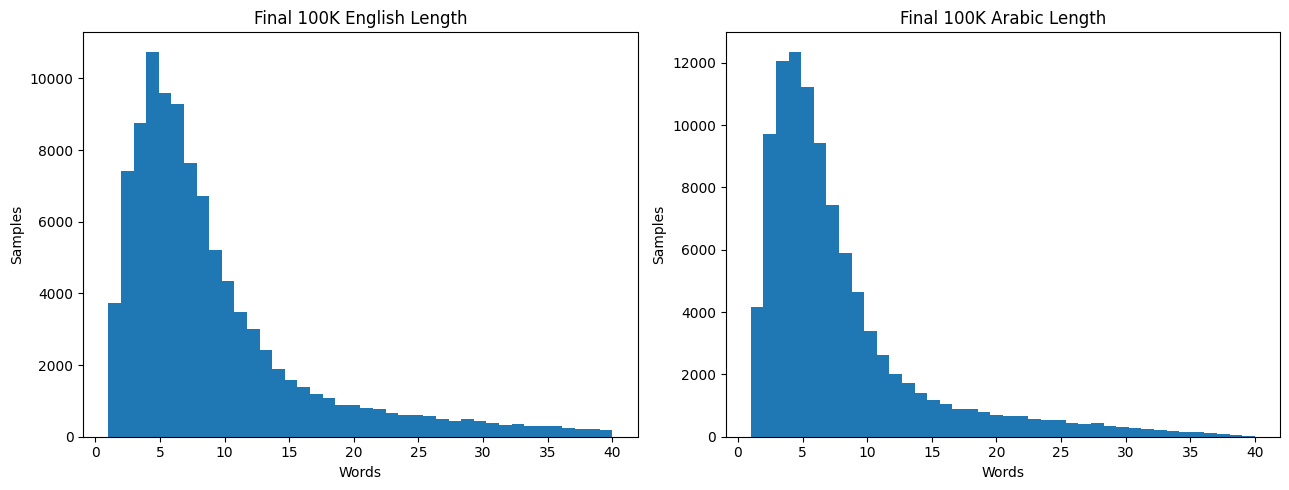

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(
    train_df["english_words"],
    bins=40,
    range=(1, 40)
)

axes[0].set_title("Final 100K English Length")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Samples")

axes[1].hist(
    train_df["arabic_words"],
    bins=40,
    range=(1, 40)
)

axes[1].set_title("Final 100K Arabic Length")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Samples")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    train_df,
    test_size=0.10,
    random_state=SEED,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 90000
Validation: 5000
Test: 5000


In [ ]:
train_pairs = set(
    zip(
        train_df["arabic"],
        train_df["english"]
    )
)

val_pairs = set(
    zip(
        val_df["arabic"],
        val_df["english"]
    )
)

test_pairs = set(
    zip(
        test_df["arabic"],
        test_df["english"]
    )
)

print("Train ∩ Validation:", len(train_pairs & val_pairs))
print("Train ∩ Test:", len(train_pairs & test_pairs))
print("Validation ∩ Test:", len(val_pairs & test_pairs))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [ ]:
bpe_train_file = DATA_DIR / "bpe_train.txt"

with open(
    bpe_train_file,
    "w",
    encoding="utf-8"
) as f:

    for text in train_df["arabic"]:
        f.write(text + "\n")

    for text in train_df["english"]:
        f.write(text + "\n")

print(bpe_train_file)

/content/nmt_data/bpe_train.txt


In [ ]:
spm.SentencePieceTrainer.train(
    input=str(bpe_train_file),
    model_prefix=str(DATA_DIR / "joint_bpe"),
    vocab_size=VOCAB_SIZE,
    model_type="bpe",
    character_coverage=0.9995,
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3
)

print("BPE model trained.")

BPE model trained.


In [ ]:
sp = spm.SentencePieceProcessor(
    model_file=str(
        DATA_DIR / "joint_bpe.model"
    )
)

print("Vocabulary size:", sp.get_piece_size())

print("PAD:", sp.pad_id())
print("UNK:", sp.unk_id())
print("BOS:", sp.bos_id())
print("EOS:", sp.eos_id())

Vocabulary size: 30000
PAD: 0
UNK: 1
BOS: 2
EOS: 3


In [ ]:
samples = train_df.sample(
    5,
    random_state=SEED
)

for _, row in samples.iterrows():

    arabic = row["arabic"]
    english = row["english"]

    arabic_tokens = sp.encode(
        arabic,
        out_type=str
    )

    english_tokens = sp.encode(
        english,
        out_type=str
    )

    print("Arabic:")
    print(arabic)
    print(arabic_tokens)

    print("\nEnglish:")
    print(english)
    print(english_tokens)

    print("\n" + "=" * 80 + "\n")

Arabic:
اذهب الآن
['▁اذهب', '▁الآن']

English:
Go now.
['▁Go', '▁now', '.']


Arabic:
(جون) مثله
['▁(', 'جون', ')', '▁مثله']

English:
John is like him.
['▁John', '▁is', '▁like', '▁him', '.']


Arabic:
حتى أن المرء يسعه الهبوط في طائرة على مدرج جليدي
['▁حتى', '▁أن', '▁المرء', '▁يس', 'عه', '▁الهبوط', '▁في', '▁طائرة', '▁على', '▁مد', 'رج', '▁جلي', 'دي']

English:
You can even land a plane on the ice runway.
['▁You', '▁can', '▁even', '▁land', '▁a', '▁plane', '▁on', '▁the', '▁ice', '▁run', 'way', '.']


Arabic:
الدورة العادية الأولى
['▁الدورة', '▁العادية', '▁الأولى']

English:
First regular session
['▁First', '▁regular', '▁session']


Arabic:
كلمة تحذير، (غوردن)، رجل شرير.
['▁كلمة', '▁تحذير', '،', '▁(', 'غ', 'وردن', ')،', '▁رجل', '▁شرير', '.']

English:
A word of warning... Gordon is a vicious man.
['▁A', '▁word', '▁of', '▁warning', '...', '▁Gordon', '▁is', '▁a', '▁v', 'icious', '▁man', '.']




In [ ]:
for text in train_df["arabic"].sample(
    10,
    random_state=SEED
):

    ids = sp.encode(
        text,
        out_type=int
    )

    reconstructed = sp.decode(ids)

    print("Original:     ", text)
    print("Reconstructed:", reconstructed)
    print("Match:", text == reconstructed)
    print()

Original:      اذهب الآن
Reconstructed: اذهب الآن
Match: True

Original:      (جون) مثله
Reconstructed: (جون) مثله
Match: True

Original:      حتى أن المرء يسعه الهبوط في طائرة على مدرج جليدي
Reconstructed: حتى أن المرء يسعه الهبوط في طائرة على مدرج جليدي
Match: True

Original:      الدورة العادية الأولى
Reconstructed: الدورة العادية الأولى
Match: True

Original:      كلمة تحذير، (غوردن)، رجل شرير.
Reconstructed: كلمة تحذير، (غوردن)، رجل شرير.
Match: True

Original:      لا يمكن.
Reconstructed: لا يمكن.
Match: True

Original:      هل تسمعني ؟
Reconstructed: هل تسمعني ؟
Match: True

Original:      -جاء وطلب ان يتحدث معي بصورة شخصية
Reconstructed: -جاء وطلب ان يتحدث معي بصورة شخصية
Match: True

Original:      أما في ما يتعلق بالاستفتاء، فلم يجر متابعته لأن أكثر من 80 في المائة من السكان قد امتنعوا عن التصويت.
Reconstructed: أما في ما يتعلق بالاستفتاء، فلم يجر متابعته لأن أكثر من 80 في المائة من السكان قد امتنعوا عن التصويت.
Match: True

Original:      -إذا ما أردت أن تسير ثانية
Reconstru

In [ ]:
def get_bpe_lengths(texts):

    return np.array([
        len(
            sp.encode(
                text,
                out_type=int
            )
        )
        for text in tqdm(
            texts,
            desc="Calculating BPE lengths"
        )
    ])


train_ar_bpe_lengths = get_bpe_lengths(
    train_df["arabic"]
)

train_en_bpe_lengths = get_bpe_lengths(
    train_df["english"]
)

Calculating BPE lengths:   0%|          | 0/90000 [00:00<?, ?it/s]

Calculating BPE lengths:   0%|          | 0/90000 [00:00<?, ?it/s]

In [ ]:
def print_bpe_stats(lengths, name):

    print(f"\n{name}")
    print("-" * 50)

    print(f"Mean:   {lengths.mean():.2f}")
    print(f"Median: {np.median(lengths):.2f}")
    print(f"Std:    {lengths.std():.2f}")
    print(f"Min:    {lengths.min()}")
    print(f"Max:    {lengths.max()}")

    for p in [90, 95, 97, 98, 99]:
        print(
            f"P{p}:    "
            f"{np.percentile(lengths, p):.2f}"
        )


print_bpe_stats(
    train_ar_bpe_lengths,
    "Arabic BPE"
)

print_bpe_stats(
    train_en_bpe_lengths,
    "English BPE"
)


Arabic BPE
--------------------------------------------------
Mean:   10.72
Median: 8.00
Std:    9.13
Min:    0
Max:    102
P90:    23.00
P95:    31.00
P97:    36.00
P98:    40.00
P99:    45.00

English BPE
--------------------------------------------------
Mean:   12.58
Median: 10.00
Std:    9.45
Min:    1
Max:    109
P90:    25.00
P95:    34.00
P97:    38.00
P98:    42.00
P99:    46.00


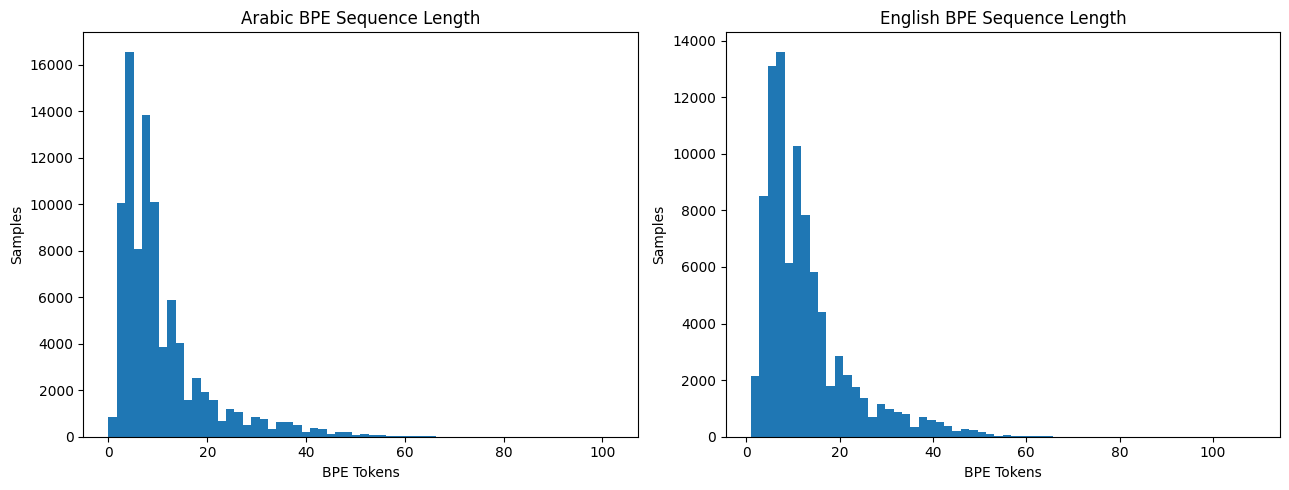

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

axes[0].hist(
    train_ar_bpe_lengths,
    bins=60
)

axes[0].set_title(
    "Arabic BPE Sequence Length"
)

axes[0].set_xlabel("BPE Tokens")
axes[0].set_ylabel("Samples")

axes[1].hist(
    train_en_bpe_lengths,
    bins=60
)

axes[1].set_title(
    "English BPE Sequence Length"
)

axes[1].set_xlabel("BPE Tokens")
axes[1].set_ylabel("Samples")

plt.tight_layout()
plt.show()

In [ ]:
zero_bpe_ar = train_df[
    train_ar_bpe_lengths == 0
]

print("Zero-length Arabic samples:", len(zero_bpe_ar))

zero_bpe_ar[
    ["arabic", "english"]
].head(20)

Zero-length Arabic samples: 1


,arabic,english
71178,‏,Mmm!


In [ ]:
MAX_LEN = 48

In [ ]:
arabic_truncated = np.sum(
    train_ar_bpe_lengths > MAX_LEN
)

english_truncated = np.sum(
    train_en_bpe_lengths > MAX_LEN
)

print(
    "Arabic sequences > MAX_LEN:",
    arabic_truncated,
    f"({arabic_truncated / len(train_df) * 100:.2f}%)"
)

print(
    "English sequences > MAX_LEN:",
    english_truncated,
    f"({english_truncated / len(train_df) * 100:.2f}%)"
)

Arabic sequences > MAX_LEN: 534 (0.59%)
English sequences > MAX_LEN: 592 (0.66%)


In [ ]:
valid_mask = train_ar_bpe_lengths > 0

print("Before:", len(train_df))

train_df = train_df.loc[
    valid_mask
].reset_index(drop=True)

train_ar_bpe_lengths = train_ar_bpe_lengths[
    valid_mask
]

train_en_bpe_lengths = train_en_bpe_lengths[
    valid_mask
]

print("After:", len(train_df))
print("Removed:", (~valid_mask).sum())

Before: 90000
After: 89999
Removed: 1


In [ ]:
MAX_LEN = 48

print("MAX_LEN:", MAX_LEN)

print(
    "Arabic truncation:",
    f"{np.mean(train_ar_bpe_lengths > MAX_LEN) * 100:.2f}%"
)

print(
    "English truncation:",
    f"{np.mean(train_en_bpe_lengths > MAX_LEN) * 100:.2f}%"
)

MAX_LEN: 48
Arabic truncation: 0.59%
English truncation: 0.66%


In [ ]:
PAD_ID = sp.pad_id()
UNK_ID = sp.unk_id()
BOS_ID = sp.bos_id()
EOS_ID = sp.eos_id()

def encode_source(text):
    ids = sp.encode(
        text,
        out_type=int
    )

    ids = ids[:MAX_LEN]

    return ids


def encode_target(text):
    ids = sp.encode(
        text,
        out_type=int
    )

    ids = ids[:MAX_LEN - 2]

    return [BOS_ID] + ids + [EOS_ID]

In [ ]:
sample_ar = train_df.iloc[0]["arabic"]
sample_en = train_df.iloc[0]["english"]

source_ids = encode_source(sample_ar)
target_ids = encode_target(sample_en)

print("Arabic:")
print(sample_ar)

print("\nArabic IDs:")
print(source_ids)

print("\nEnglish:")
print(sample_en)

print("\nEnglish IDs:")
print(target_ids)

print("\nSource length:", len(source_ids))
print("Target length:", len(target_ids))

Arabic:
اجل , انظرى , سبعة اوجة حزينة

Arabic IDs:
[3774, 331, 29059, 331, 11511, 102, 375, 29910, 3266, 1293]

English:
Yeah, look. Seven sad faces.

English IDs:
[2, 687, 29918, 932, 29896, 19986, 8370, 15670, 29896, 3]

Source length: 10
Target length: 10


In [ ]:
def pad_sequence(ids, max_len):
    ids = ids[:max_len]

    return ids + [PAD_ID] * (
        max_len - len(ids)
    )

In [ ]:
def encode_dataframe(df):

    sources = []
    targets = []

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc="Encoding"
    ):
        source = encode_source(row["arabic"])
        target = encode_target(row["english"])

        sources.append(
            pad_sequence(source, MAX_LEN)
        )

        targets.append(
            pad_sequence(target, MAX_LEN)
        )

    return (
        np.asarray(sources, dtype=np.int32),
        np.asarray(targets, dtype=np.int32)
    )

In [ ]:
X_train, Y_train = encode_dataframe(train_df)

X_val, Y_val = encode_dataframe(val_df)

X_test, Y_test = encode_dataframe(test_df)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)

print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

Encoding:   0%|          | 0/89999 [00:00<?, ?it/s]

Encoding:   0%|          | 0/5000 [00:00<?, ?it/s]

Encoding:   0%|          | 0/5000 [00:00<?, ?it/s]

X_train: (89999, 48)
Y_train: (89999, 48)
X_val: (5000, 48)
Y_val: (5000, 48)
X_test: (5000, 48)
Y_test: (5000, 48)


In [ ]:
decoder_inputs_train = Y_train[:, :-1]
decoder_targets_train = Y_train[:, 1:]

decoder_inputs_val = Y_val[:, :-1]
decoder_targets_val = Y_val[:, 1:]

decoder_inputs_test = Y_test[:, :-1]
decoder_targets_test = Y_test[:, 1:]

print(
    "Decoder input:",
    decoder_inputs_train.shape
)

print(
    "Decoder target:",
    decoder_targets_train.shape
)

Decoder input: (89999, 47)
Decoder target: (89999, 47)


In [ ]:
print("Decoder input IDs:")
print(decoder_inputs_train[0][:20])

print("\nDecoder target IDs:")
print(decoder_targets_train[0][:20])

Decoder input IDs:
[    2   687 29918   932 29896 19986  8370 15670 29896     3     0     0
     0     0     0     0     0     0     0     0]

Decoder target IDs:
[  687 29918   932 29896 19986  8370 15670 29896     3     0     0     0
     0     0     0     0     0     0     0     0]


In [ ]:
print(
    np.array_equal(
        decoder_inputs_train[0, 1:],
        decoder_targets_train[0, :-1]
    )
)

True


In [ ]:
BATCH_SIZE = 128

train_ds = tf.data.Dataset.from_tensor_slices(
    (
        X_train,
        decoder_inputs_train,
        decoder_targets_train
    )
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (
        X_val,
        decoder_inputs_val,
        decoder_targets_val
    )
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (
        X_test,
        decoder_inputs_test,
        decoder_targets_test
    )
)

In [ ]:
train_ds = (
    train_ds
    .shuffle(
        len(X_train),
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
source_batch, decoder_input_batch, decoder_target_batch = next(
    iter(train_ds)
)

print("Source:", source_batch.shape)
print("Decoder input:", decoder_input_batch.shape)
print("Decoder target:", decoder_target_batch.shape)

Source: (128, 48)
Decoder input: (128, 47)
Decoder target: (128, 47)


In [ ]:
print("PAD ID:", PAD_ID)

print(
    "Source PAD count:",
    np.sum(X_train == PAD_ID)
)

print(
    "Target PAD count:",
    np.sum(Y_train == PAD_ID)
)

PAD ID: 0
Source PAD count: 3358121
Target PAD count: 3013215


In [ ]:
EMBED_DIM = 256

ENCODER_UNITS = 256
DECODER_UNITS = 512

DROPOUT_RATE = 0.15

VOCAB_SIZE = sp.get_piece_size()

print("Vocabulary:", VOCAB_SIZE)
print("Embedding dim:", EMBED_DIM)
print("Encoder units:", ENCODER_UNITS)
print("Decoder units:", DECODER_UNITS)

Vocabulary: 30000
Embedding dim: 256
Encoder units: 256
Decoder units: 512


In [ ]:
class Encoder(tf.keras.Model):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        enc_units,
        dropout_rate=0.0
    ):
        super().__init__()

        self.embedding = layers.Embedding(
            vocab_size,
            embed_dim,
            mask_zero=True
        )

        self.bilstm = layers.Bidirectional(
            layers.LSTM(
                enc_units,
                return_sequences=True,
                return_state=True,
                dropout=dropout_rate
            )
        )

    def call(self, x, training=False):

        x = self.embedding(x)

        outputs, forward_h, forward_c, backward_h, backward_c = self.bilstm(
            x,
            training=training
        )

        hidden = tf.concat(
            [forward_h, backward_h],
            axis=-1
        )

        cell = tf.concat(
            [forward_c, backward_c],
            axis=-1
        )

        return outputs, hidden, cell

In [ ]:
encoder = Encoder(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    enc_units=ENCODER_UNITS,
    dropout_rate=DROPOUT_RATE
)

sample_source = source_batch[:2]

encoder_outputs, encoder_hidden, encoder_cell = encoder(
    sample_source
)

print("Encoder outputs:", encoder_outputs.shape)
print("Encoder hidden:", encoder_hidden.shape)
print("Encoder cell:", encoder_cell.shape)

Encoder outputs: (2, 48, 512)
Encoder hidden: (2, 512)
Encoder cell: (2, 512)


In [ ]:
class BahdanauAttention(layers.Layer):

    def __init__(
        self,
        units
    ):
        super().__init__()

        self.W1 = layers.Dense(units)
        self.W2 = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(
        self,
        query,
        values,
        mask=None
    ):

        query = tf.expand_dims(
            query,
            axis=1
        )

        score = self.V(
            tf.nn.tanh(
                self.W1(values) +
                self.W2(query)
            )
        )

        score = tf.squeeze(
            score,
            axis=-1
        )

        if mask is not None:
            score = tf.where(
                mask,
                score,
                tf.fill(
                    tf.shape(score),
                    tf.constant(-1e9)
                )
            )

        attention_weights = tf.nn.softmax(
            score,
            axis=1
        )

        context = tf.reduce_sum(
            values *
            tf.expand_dims(
                attention_weights,
                axis=-1
            ),
            axis=1
        )

        return context, attention_weights

In [ ]:
attention = BahdanauAttention(
    DECODER_UNITS
)

source_mask = tf.not_equal(
    sample_source,
    PAD_ID
)

context, attention_weights = attention(
    encoder_hidden,
    encoder_outputs,
    source_mask
)

print("Context:", context.shape)
print("Attention:", attention_weights.shape)
print("Attention sum:", attention_weights[0].numpy().sum())

Context: (2, 512)
Attention: (2, 48)
Attention sum: 1.0


In [ ]:
class Bridge(layers.Layer):

    def __init__(self, decoder_units):
        super().__init__()

        self.hidden_projection = layers.Dense(
            decoder_units,
            activation="tanh"
        )

        self.cell_projection = layers.Dense(
            decoder_units,
            activation="tanh"
        )

    def call(self, hidden, cell):

        hidden = self.hidden_projection(hidden)
        cell = self.cell_projection(cell)

        return hidden, cell

In [ ]:
class Decoder(tf.keras.Model):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        decoder_units,
        attention,
        dropout_rate=0.0
    ):
        super().__init__()

        self.embedding = layers.Embedding(
            vocab_size,
            embed_dim,
            mask_zero=True
        )

        self.lstm = layers.LSTM(
            decoder_units,
            return_sequences=True,
            return_state=True,
            dropout=dropout_rate
        )

        self.attention = attention

        self.dropout = layers.Dropout(
            dropout_rate
        )

    def call(
        self,
        x,
        hidden,
        cell,
        encoder_outputs,
        encoder_mask,
        training=False
    ):

        x = self.embedding(x)

        outputs = []
        attention_scores = []

        for t in range(x.shape[1]):

            current_embedding = x[:, t, :]

            context, weights = self.attention(
                hidden,
                encoder_outputs,
                encoder_mask
            )

            lstm_input = tf.concat(
                [
                    tf.expand_dims(
                        current_embedding,
                        axis=1
                    ),
                    tf.expand_dims(
                        context,
                        axis=1
                    )
                ],
                axis=-1
            )

            output, hidden, cell = self.lstm(
                lstm_input,
                initial_state=[
                    hidden,
                    cell
                ],
                training=training
            )

            output = self.dropout(
                output,
                training=training
            )

            outputs.append(output)
            attention_scores.append(weights)

        outputs = tf.concat(
            outputs,
            axis=1
        )

        attention_scores = tf.stack(
            attention_scores,
            axis=1
        )

        return (
            outputs,
            hidden,
            cell,
            attention_scores
        )

In [ ]:
class Decoder(tf.keras.Model):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        decoder_units,
        attention,
        dropout_rate=0.0
    ):
        super().__init__()

        self.embedding = layers.Embedding(
            vocab_size,
            embed_dim,
            mask_zero=True
        )

        self.lstm = layers.LSTM(
            decoder_units,
            return_sequences=True,
            return_state=True,
            dropout=dropout_rate
        )

        self.attention = attention

        self.dropout = layers.Dropout(
            dropout_rate
        )

    def call(
        self,
        x,
        hidden,
        cell,
        encoder_outputs,
        encoder_mask,
        training=False
    ):

        x = self.embedding(x)

        outputs = []
        contexts = []
        embeddings = []
        attention_scores = []

        for t in range(x.shape[1]):

            current_embedding = x[:, t, :]

            context, weights = self.attention(
                hidden,
                encoder_outputs,
                encoder_mask
            )

            lstm_input = tf.concat(
                [
                    tf.expand_dims(
                        current_embedding,
                        axis=1
                    ),
                    tf.expand_dims(
                        context,
                        axis=1
                    )
                ],
                axis=-1
            )

            output, hidden, cell = self.lstm(
                lstm_input,
                initial_state=[
                    hidden,
                    cell
                ],
                training=training
            )

            output = self.dropout(
                output,
                training=training
            )

            outputs.append(output)
            contexts.append(context)
            embeddings.append(current_embedding)
            attention_scores.append(weights)

        outputs = tf.concat(
            outputs,
            axis=1
        )

        contexts = tf.stack(
            contexts,
            axis=1
        )

        embeddings = tf.stack(
            embeddings,
            axis=1
        )

        attention_scores = tf.stack(
            attention_scores,
            axis=1
        )

        return (
            outputs,
            contexts,
            embeddings,
            hidden,
            cell,
            attention_scores
        )

In [ ]:
attention = BahdanauAttention(
    DECODER_UNITS
)

encoder = Encoder(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    enc_units=ENCODER_UNITS,
    dropout_rate=DROPOUT_RATE
)

bridge = Bridge(
    DECODER_UNITS
)

decoder = Decoder(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    decoder_units=DECODER_UNITS,
    attention=attention,
    dropout_rate=DROPOUT_RATE
)

print("Components created.")

Components created.


In [ ]:
sample_source = source_batch[:2]
sample_decoder_input = decoder_input_batch[:2]

encoder_outputs, encoder_hidden, encoder_cell = encoder(
    sample_source,
    training=False
)

encoder_mask = tf.not_equal(
    sample_source,
    PAD_ID
)

decoder_hidden, decoder_cell = bridge(
    encoder_hidden,
    encoder_cell
)

(
    decoder_outputs,
    contexts,
    embeddings,
    decoder_hidden,
    decoder_cell,
    attention_scores
) = decoder(
    sample_decoder_input,
    decoder_hidden,
    decoder_cell,
    encoder_outputs,
    encoder_mask,
    training=False
)

print("Encoder:", encoder_outputs.shape)
print("Decoder:", decoder_outputs.shape)
print("Contexts:", contexts.shape)
print("Embeddings:", embeddings.shape)
print("Attention:", attention_scores.shape)

Encoder: (2, 48, 512)
Decoder: (2, 47, 512)
Contexts: (2, 47, 512)
Embeddings: (2, 47, 256)
Attention: (2, 47, 48)


In [ ]:
class OutputProjection(tf.keras.layers.Layer):

    def __init__(
        self,
        vocab_size,
        hidden_dim=512,
        dropout_rate=0.0
    ):
        super().__init__()

        self.projection = layers.Dense(
            hidden_dim,
            activation="tanh"
        )

        self.dropout = layers.Dropout(
            dropout_rate
        )

        self.vocab_projection = layers.Dense(
            vocab_size
        )

    def call(
        self,
        decoder_outputs,
        contexts,
        embeddings,
        training=False
    ):

        x = tf.concat(
            [
                decoder_outputs,
                contexts,
                embeddings
            ],
            axis=-1
        )

        x = self.projection(x)

        x = self.dropout(
            x,
            training=training
        )

        return self.vocab_projection(x)

In [ ]:
output_projection = OutputProjection(
    vocab_size=VOCAB_SIZE,
    hidden_dim=512,
    dropout_rate=DROPOUT_RATE
)

logits = output_projection(
    decoder_outputs,
    contexts,
    embeddings,
    training=False
)

print("Logits:", logits.shape)

Logits: (2, 47, 30000)


In [ ]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True,
    reduction="none"
)

In [ ]:
def masked_loss(y_true, y_pred):

    loss = loss_object(
        y_true,
        y_pred
    )

    mask = tf.cast(
        tf.not_equal(
            y_true,
            PAD_ID
        ),
        loss.dtype
    )

    loss *= mask

    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

In [ ]:
sample_targets = decoder_target_batch[:2]

loss_value = masked_loss(
    sample_targets,
    logits
)

print("Loss:", float(loss_value))

Loss: 10.309279441833496


In [ ]:
INITIAL_LR = 5e-4

optimizer = tf.keras.optimizers.Adam(
    learning_rate=INITIAL_LR,
    beta_1=0.9,
    beta_2=0.98
)

print(optimizer)

In [ ]:
class NMTModel(tf.keras.Model):

    def __init__(
        self,
        encoder,
        bridge,
        decoder,
        output_projection
    ):
        super().__init__()

        self.encoder = encoder
        self.bridge = bridge
        self.decoder = decoder
        self.output_projection = output_projection

    def call(
        self,
        source,
        decoder_input,
        training=False
    ):

        encoder_outputs, encoder_hidden, encoder_cell = self.encoder(
            source,
            training=training
        )

        encoder_mask = tf.not_equal(
            source,
            PAD_ID
        )

        decoder_hidden, decoder_cell = self.bridge(
            encoder_hidden,
            encoder_cell
        )

        (
            decoder_outputs,
            contexts,
            embeddings,
            _,
            _,
            attention_scores
        ) = self.decoder(
            decoder_input,
            decoder_hidden,
            decoder_cell,
            encoder_outputs,
            encoder_mask,
            training=training
        )

        logits = self.output_projection(
            decoder_outputs,
            contexts,
            embeddings,
            training=training
        )

        return logits, attention_scores

In [ ]:
model = NMTModel(
    encoder=encoder,
    bridge=bridge,
    decoder=decoder,
    output_projection=output_projection
)

print("Model created.")

Model created.


In [ ]:
sample_logits, sample_attention = model(
    source_batch[:2],
    decoder_input_batch[:2],
    training=False
)

print("Logits:", sample_logits.shape)
print("Attention:", sample_attention.shape)
print(
    "Finite logits:",
    bool(tf.reduce_all(tf.math.is_finite(sample_logits)))
)

Logits: (2, 47, 30000)
Attention: (2, 47, 48)
Finite logits: True


In [ ]:
loss_value = masked_loss(
    decoder_target_batch[:2],
    sample_logits
)

print("Initial loss:", float(loss_value))
print(
    "Finite loss:",
    bool(tf.math.is_finite(loss_value))
)

Initial loss: 10.309279441833496
Finite loss: True


In [ ]:
with tf.GradientTape() as tape:

    logits, _ = model(
        source_batch[:2],
        decoder_input_batch[:2],
        training=True
    )

    loss = masked_loss(
        decoder_target_batch[:2],
        logits
    )

gradients = tape.gradient(
    loss,
    model.trainable_variables
)

valid_gradients = [
    g for g in gradients
    if g is not None
]

finite_gradients = all(
    bool(tf.reduce_all(tf.math.is_finite(g)))
    for g in valid_gradients
)

print("Loss:", float(loss))
print("Trainable variables:", len(model.trainable_variables))
print("Gradients:", len(valid_gradients))
print("All gradients finite:", finite_gradients)

Loss: 10.309423446655273
Trainable variables: 25
Gradients: 25
All gradients finite: True


In [ ]:
gradient_norm = tf.linalg.global_norm(
    valid_gradients
)

print(
    "Global gradient norm:",
    float(gradient_norm)
)

Global gradient norm: 0.23138217628002167


In [ ]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=INITIAL_LR,
    beta_1=0.9,
    beta_2=0.98,
    clipnorm=1.0
)

print(optimizer)

In [ ]:
@tf.function
def train_step(
    source,
    decoder_input,
    decoder_target
):

    with tf.GradientTape() as tape:

        logits, _ = model(
            source,
            decoder_input,
            training=True
        )

        loss = masked_loss(
            decoder_target,
            logits
        )

    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    return loss

In [ ]:
@tf.function
def validation_step(
    source,
    decoder_input,
    decoder_target
):

    logits, _ = model(
        source,
        decoder_input,
        training=False
    )

    loss = masked_loss(
        decoder_target,
        logits
    )

    return loss

In [ ]:
SANITY_STEPS = 50

sanity_losses = []

for step, (
    source,
    decoder_input,
    decoder_target
) in enumerate(train_ds.take(SANITY_STEPS)):

    loss = train_step(
        source,
        decoder_input,
        decoder_target
    )

    sanity_losses.append(
        float(loss)
    )

    if (step + 1) % 10 == 0:
        print(
            f"Step {step + 1:02d} | "
            f"Loss: {loss:.4f}"
        )

Step 10 | Loss: 10.0367
Step 20 | Loss: 7.0495
Step 30 | Loss: 6.8553
Step 40 | Loss: 7.1422
Step 50 | Loss: 6.9892


In [ ]:
print(
    "Initial sanity loss:",
    sanity_losses[0]
)

print(
    "Final sanity loss:",
    sanity_losses[-1]
)

print(
    "Improvement:",
    sanity_losses[0] - sanity_losses[-1]
)

Initial sanity loss: 10.308774948120117
Final sanity loss: 6.989153861999512
Improvement: 3.3196210861206055


In [ ]:
val_losses = []

for source, decoder_input, decoder_target in val_ds:

    loss = validation_step(
        source,
        decoder_input,
        decoder_target
    )

    val_losses.append(
        float(loss)
    )

initial_val_loss = np.mean(val_losses)

print(
    f"Validation loss after sanity run: "
    f"{initial_val_loss:.4f}"
)

Validation loss after sanity run: 6.8880


In [ ]:
EPOCHS = 20

PATIENCE = 3
MIN_DELTA = 0.001

best_val_loss = float("inf")
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "learning_rate": []
}

In [ ]:
BEST_MODEL_PATH = CHECKPOINT_DIR / "best_model.weights.h5"

print(BEST_MODEL_PATH)

/content/nmt_checkpoints/best_model.weights.h5


In [ ]:
import time

In [ ]:
for epoch in range(EPOCHS):

    start_time = time.time()

    train_losses = []

    train_bar = tqdm(
        train_ds,
        total=tf.data.experimental.cardinality(train_ds).numpy(),
        desc=f"Epoch {epoch + 1}/{EPOCHS} [Train]",
        leave=True
    )

    for source, decoder_input, decoder_target in train_bar:

        loss = train_step(
            source,
            decoder_input,
            decoder_target
        )

        loss_value = float(loss)
        train_losses.append(loss_value)

        train_bar.set_postfix(
            loss=f"{loss_value:.4f}"
        )

    train_loss = np.mean(train_losses)

    val_losses = []

    val_bar = tqdm(
        val_ds,
        total=tf.data.experimental.cardinality(val_ds).numpy(),
        desc=f"Epoch {epoch + 1}/{EPOCHS} [Val]",
        leave=True
    )

    for source, decoder_input, decoder_target in val_bar:

        loss = validation_step(
            source,
            decoder_input,
            decoder_target
        )

        loss_value = float(loss)
        val_losses.append(loss_value)

        val_bar.set_postfix(
            loss=f"{loss_value:.4f}"
        )

    val_loss = np.mean(val_losses)

    current_lr = float(
        tf.keras.backend.get_value(
            optimizer.learning_rate
        )
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["learning_rate"].append(current_lr)

    elapsed = time.time() - start_time

    print(
        f"\nEpoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"LR: {current_lr:.6f} | "
        f"Time: {elapsed / 60:.2f} min"
    )

    if val_loss < best_val_loss - MIN_DELTA:

        best_val_loss = val_loss
        epochs_without_improvement = 0

        model.save_weights(
            BEST_MODEL_PATH
        )

        print(
            f"Best model saved: "
            f"{best_val_loss:.4f}"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"No improvement: "
            f"{epochs_without_improvement}/{PATIENCE}"
        )

        if epochs_without_improvement >= PATIENCE:

            print("Early stopping.")
            break

Epoch 1/20 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/40 [00:00<?, ?it/s]


Epoch 01/20 | Train Loss: 5.1742 | Val Loss: 4.7893 | LR: 0.000500 | Time: 9.59 min
Best model saved: 4.7893


Epoch 2/20 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 2/20 [Val]:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/40 [00:00<?, ?it/s]


Epoch 19/20 | Train Loss: 2.2914 | Val Loss: 3.4632 | LR: 0.000500 | Time: 9.38 min
No improvement: 2/3


Epoch 20/20 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/40 [00:00<?, ?it/s]


Epoch 20/20 | Train Loss: 2.2223 | Val Loss: 3.4728 | LR: 0.000500 | Time: 9.38 min
No improvement: 3/3
Early stopping.


In [ ]:
model.load_weights(BEST_MODEL_PATH)

print("Best model loaded.")
print("Best validation loss:", best_val_loss)

Best model loaded.
Best validation loss: 3.45448699593544


In [ ]:
def translate_sentence(
    arabic_text,
    max_len=MAX_LEN
):

    source_ids = encode_source(arabic_text)

    source_ids = pad_sequence(
        source_ids,
        MAX_LEN
    )

    source = tf.convert_to_tensor(
        [source_ids],
        dtype=tf.int32
    )

    encoder_outputs, encoder_hidden, encoder_cell = encoder(
        source,
        training=False
    )

    encoder_mask = tf.not_equal(
        source,
        PAD_ID
    )

    hidden, cell = bridge(
        encoder_hidden,
        encoder_cell
    )

    generated_ids = [BOS_ID]

    attention_history = []

    for _ in range(max_len - 1):

        current_token = tf.convert_to_tensor(
            [[generated_ids[-1]]],
            dtype=tf.int32
        )

        embedding = decoder.embedding(
            current_token
        )

        context, attention_weights = attention(
            hidden,
            encoder_outputs,
            encoder_mask
        )

        lstm_input = tf.concat(
            [
                embedding,
                tf.expand_dims(
                    context,
                    axis=1
                )
            ],
            axis=-1
        )

        output, hidden, cell = decoder.lstm(
            lstm_input,
            initial_state=[
                hidden,
                cell
            ],
            training=False
        )

        output = decoder.dropout(
            output,
            training=False
        )

        logits = output_projection(
            output,
            tf.expand_dims(context, axis=1),
            embedding,
            training=False
        )

        next_token = tf.argmax(
            logits[0, 0],
            axis=-1
        ).numpy()

        generated_ids.append(
            int(next_token)
        )

        attention_history.append(
            attention_weights[0].numpy()
        )

        if next_token == EOS_ID:
            break

    generated_ids = generated_ids[1:]

    if EOS_ID in generated_ids:
        generated_ids = generated_ids[
            :generated_ids.index(EOS_ID)
        ]

    translation = sp.decode(
        generated_ids
    )

    return translation, attention_history

In [ ]:
for i in range(10):

    arabic = test_df.iloc[i]["arabic"]
    reference = test_df.iloc[i]["english"]

    prediction, _ = translate_sentence(
        arabic
    )

    print(f"Arabic:     {arabic}")
    print(f"Reference:  {reference}")
    print(f"Prediction: {prediction}")
    print("-" * 100)

Arabic:     لا , توقفي
Reference:  No, stop it. Stop it.
Prediction: No, stop.
----------------------------------------------------------------------------------------------------
Arabic:     لا اكبر فى الحجم ولكن والدك اقوى
Reference:  No. Bigger in size, but Daddy is stronger.
Prediction: No one of the pain, but your dad.
----------------------------------------------------------------------------------------------------
Arabic:     5-9 وفيما يخص استنفاد سبل الانتصاف المحلية، وبالاستناد إلى قرارات اللجنة السابقة()، يدفع أصحاب البلاغ بأن العهد يقضي برفع دعوى جنائية على الصعيد الوطني في حالة وقوع انتهاكات جسيمة ولا سيما حالات وفاة غير مشروعة.
Reference:  5.9 As to the exhaustion of domestic remedies, the authors, referring to the Committee's jurisprudence, state that the Covenant requires criminal proceedings to be initiated at the national level in the case of serious violations, and in particular unlawful deaths.
Prediction: With regard to domestic local remedies, in the decisions of

In [ ]:
references = []
predictions = []

for i in tqdm(
    range(len(test_df)),
    desc="Translating test set"
):

    arabic = test_df.iloc[i]["arabic"]
    reference = test_df.iloc[i]["english"]

    prediction, _ = translate_sentence(
        arabic
    )

    references.append(
        reference
    )

    predictions.append(
        prediction
    )

print("References:", len(references))
print("Predictions:", len(predictions))

Translating test set:   0%|          | 0/5000 [00:00<?, ?it/s]

References: 5000
Predictions: 5000


In [ ]:
bleu = sacrebleu.corpus_bleu(
    predictions,
    [references],
    tokenize="13a"
)

print(bleu)
print(f"\nBLEU Score: {bleu.score:.4f}")

BLEU = 12.92 40.9/16.6/8.7/4.7 (BP = 1.000 ratio = 1.033 hyp_len = 55981 ref_len = 54211)

BLEU Score: 12.9167


In [ ]:
print(f"BLEU: {bleu.score:.2f}")
print(f"1-gram: {bleu.precisions[0]:.2f}%")
print(f"2-gram: {bleu.precisions[1]:.2f}%")
print(f"3-gram: {bleu.precisions[2]:.2f}%")
print(f"4-gram: {bleu.precisions[3]:.2f}%")
print(f"Brevity Penalty: {bleu.bp:.4f}")

BLEU: 12.92
1-gram: 40.95%
2-gram: 16.62%
3-gram: 8.65%
4-gram: 4.73%
Brevity Penalty: 1.0000


In [ ]:
def translate_sentence(text, max_len=MAX_LEN):

    source_ids = encode_source(text)
    source_ids = pad_sequence(source_ids, MAX_LEN)

    source = tf.convert_to_tensor(
        [source_ids],
        dtype=tf.int32
    )

    encoder_outputs, encoder_hidden, encoder_cell = encoder(
        source,
        training=False
    )

    encoder_mask = tf.not_equal(
        source,
        PAD_ID
    )

    hidden, cell = bridge(
        encoder_hidden,
        encoder_cell
    )

    generated = [BOS_ID]
    attention_history = []

    for _ in range(max_len - 1):

        decoder_input = tf.convert_to_tensor(
            [[generated[-1]]],
            dtype=tf.int32
        )

        embedding = decoder.embedding(
            decoder_input
        )

        context, attention_weights = attention(
            hidden,
            encoder_outputs,
            encoder_mask
        )

        lstm_input = tf.concat(
            [
                embedding,
                tf.expand_dims(context, 1)
            ],
            axis=-1
        )

        output, hidden, cell = decoder.lstm(
            lstm_input,
            initial_state=[hidden, cell],
            training=False
        )

        output = decoder.dropout(
            output,
            training=False
        )

        logits = output_projection(
            output,
            tf.expand_dims(context, 1),
            embedding,
            training=False
        )

        next_token = int(
            tf.argmax(
                logits[0, 0],
                axis=-1
            ).numpy()
        )

        generated.append(next_token)

        attention_history.append(
            attention_weights[0].numpy()
        )

        if next_token == EOS_ID:
            break

    generated = generated[1:]

    if EOS_ID in generated:
        generated = generated[:generated.index(EOS_ID)]

    translation = sp.decode(generated)

    return translation, attention_history

In [ ]:
official_test = dataset["test"]

for i in range(10):

    arabic = official_test[i]["translation"]["ar"]
    reference = official_test[i]["translation"]["en"]

    prediction, _ = translate_sentence(arabic)

    print(f"Arabic:     {arabic}")
    print(f"Reference:  {reference}")
    print(f"Prediction: {prediction}")
    print("-" * 100)

Arabic:     حسناً ، تبعاً للتقرير هناك ثلاث عبوات ماء مفقودة
Reference:  Well, according to the report, there were three water bottles missing.
Prediction: Well, we're on a three-year-fromagnium.
----------------------------------------------------------------------------------------------------
Arabic:     81 - استعرضت اللجنة البيانات التي طلبتها من المؤسسات عن صعوبات التوظيف والاستبقاء.
Reference:  The Commission reviewed the data on recruitment and retention difficulties, which it had requested from the organizations.
Prediction: The Advisory Committee notes that the institutions of the institutions involved in the process of progress was also to be implemented.
----------------------------------------------------------------------------------------------------
Arabic:     هل سترجع للعيش معنا هنا
Reference:  (Maya) So Are You Gonna Move Back In,
Prediction: You're gonna go to live with us.
----------------------------------------------------------------------------------------------

In [ ]:
references = []
predictions = []

for row in tqdm(
    official_test,
    desc="Translating official test set"
):

    arabic = row["translation"]["ar"]
    english = row["translation"]["en"]

    prediction, _ = translate_sentence(arabic)

    references.append(english)
    predictions.append(prediction)

print("Test samples:", len(predictions))

Translating official test set:   0%|          | 0/2000 [00:00<?, ?it/s]

Test samples: 2000


In [ ]:
bleu = sacrebleu.corpus_bleu(
    predictions,
    [references],
    tokenize="13a"
)

print(bleu)
print(f"\nBLEU Score: {bleu.score:.4f}")

BLEU = 11.50 40.4/15.8/7.9/4.3 (BP = 0.949 ratio = 0.950 hyp_len = 25048 ref_len = 26367)

BLEU Score: 11.5032


In [ ]:
official_test_results = pd.DataFrame({
    "arabic": [
        row["translation"]["ar"]
        for row in official_test
    ],
    "reference": references,
    "prediction": predictions
})

official_test_results.to_csv(
    DATA_DIR / "official_test_predictions.csv",
    index=False,
    encoding="utf-8"
)

print(
    f"Saved to: "
    f"{DATA_DIR / 'official_test_predictions.csv'}"
)

Saved to: /content/nmt_data/official_test_predictions.csv
